# Notebook for constructing age models for the Mamainse Point Volcanics

In [14]:
using Pkg
Pkg.activate("../")
using Chron
using Plots, DelimitedFiles
using DataFrames, CSV
using Statistics, StatsBase

include("MCR_age_models.jl")

  Activating project at `~/Github/APWP_StratModels/code`


plot_posterior_paths (generic function with 1 method)

## Maminase Point Volcanics

- The bottom of the section (lower R1 pole) is > ca. 1107 Ma, let's set it to be 1110 Ma which is thought to be the beginnin of the Midcontinent Rift
- The Flour Bay Tuff is dated to be 1100.36 $\pm$ 0.25 Ma which can be used as one constraint at strat height 2000
- The top of the section is of normal polarity with no radiometric constraints, let's set it to be 1090 $\pm$ 4 Ma

In [15]:
Mamainse_Name = ("Base of Mamainse", "Agate Point rhyolite flow", "Top of Osler") # Et cetera
Mamainse_Age           = [ 1110, 1100.36, 1090] # Measured ages
Mamainse_Age_sigma     = [ 2/2,     0.25/2, 4/2] # Measured 1-σ uncertainties
Mamainse_Height        = [ 0.0,     2000,  4100] # Depths below surface should be negative
Mamainse_Age_Sidedness = [0, 0, 0] # Sidedness (zeros by default: geochron constraints are two-sided). Use -1 for a maximum age and +1 for a minimum age, 0 for two-sided

Mamainse_Path = "../../data/age_models_output/Mamainse_Point_Volcanic_Group" # Where do you want output files to be stored

# construct the section (ChronAgeData object)
Mamainse_section = make_ChronAgeData(Mamainse_Name, Mamainse_Age, Mamainse_Age_sigma, Mamainse_Height, Mamainse_Age_Sidedness, Mamainse_Path, Age_Unit="Ma", Height_Unit="m")

ChronAgeData{3}(("Base of Mamainse", "Agate Point rhyolite flow", "Top of Osler"), [0.0, 2000.0, 4100.0], [0.01, 0.01, 0.01], [1110.0, 1100.36, 1090.0], [1.0, 0.125, 2.0], [NaN, NaN, NaN], [NaN, NaN, NaN], [NaN, NaN, NaN], [NaN, NaN, NaN], [0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [#undef, #undef, #undef], (:Chronometer, :Chronometer, :Chronometer), [NaN NaN NaN; NaN NaN NaN; … ; NaN NaN NaN; NaN NaN NaN], "../../data/age_models_output/Mamainse_Point_Volcanic_Group", 2, "Ma", "m", :cdf)

In [16]:
Mamainse_age_model_config, Mamainse_age_model_mdl, Mamainse_age_model_agedist, Mamainse_age_model_lldist = run_age_model(Mamainse_section, 10, 0.20, 1000, save_results=false, plot_results=false)

┌ Info: Generating stratigraphic age-depth model...
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/zKIt8/src/StratMetropolis.jl:28
┌ Info: Burn-in: 575000 steps
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/zKIt8/src/StratMetropolis.jl:626
Burn-in... 100%|█████████████████████████████████████████| Time: 0:00:00
┌ Info: Collecting sieved stationary distribution: 575000 steps
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/zKIt8/src/StratMetropolis.jl:689
Collecting... 100%|██████████████████████████████████████| Time: 0:00:00


(StratAgeModelConfiguration(10.0, 575000, 1000, 575, 0.2), StratAgeModel([0.0, 10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0, 80.0, 90.0  …  4010.0, 4020.0, 4030.0, 4040.0, 4050.0, 4060.0, 4070.0, 4080.0, 4090.0, 4100.0], [1110.0687135064047, 1110.0168649247203, 1109.978928536606, 1109.9305696944655, 1109.8699930274063, 1109.8110763793493, 1109.7473516660948, 1109.6981933750753, 1109.6520895386495, 1109.603895745665  …  1090.394840703814, 1090.352658857901, 1090.3006208530207, 1090.260938251916, 1090.2181197155003, 1090.1630863476844, 1090.1121012354313, 1090.0690342351384, 1090.0282518675838, 1089.961495703269], [0.9357144116692117, 0.979746428934637, 1.0013900948969863, 1.0324202634476092, 1.0875447752687748, 1.1265851895579078, 1.1850516041489014, 1.2166131967609646, 1.2585239101132908, 1.274870789105098  …  1.6636495766689563, 1.6477991883278704, 1.612989446596527, 1.6002729713347683, 1.5883539144669385, 1.5648855534333759, 1.5404858639618797, 1.5118310517557458, 1.491139327360567, 1.45

### posterior summary age model

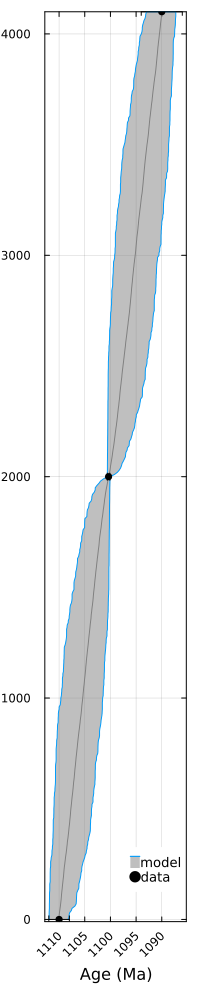

In [17]:
Mamainse_age_model = plot_age_model(Mamainse_section, Mamainse_age_model_mdl, save_figure=false)
plot!(ylim=(-10, 4100))
# savefig(Mamainse_age_model, Mamainse_section.Path*"_AgeDepthModel.pdf")
display(Mamainse_age_model)

### example posterior accumulation models

  0.004664 seconds (17.00 k allocations: 13.748 MiB, 38.00% gc time)


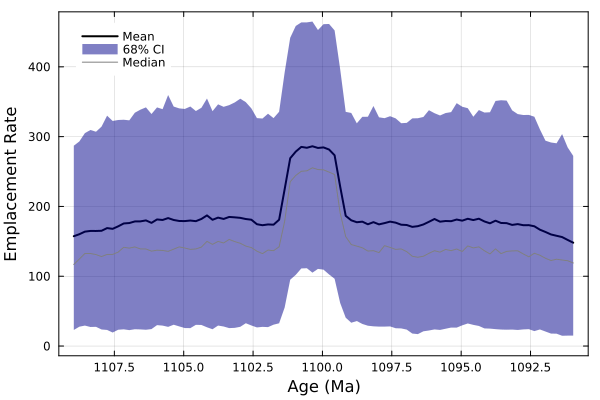

In [18]:
plot_accumulation_model(Mamainse_section, Mamainse_age_model_config, Mamainse_age_model_mdl, Mamainse_age_model_agedist, save_figure=false)

### example posterior age models

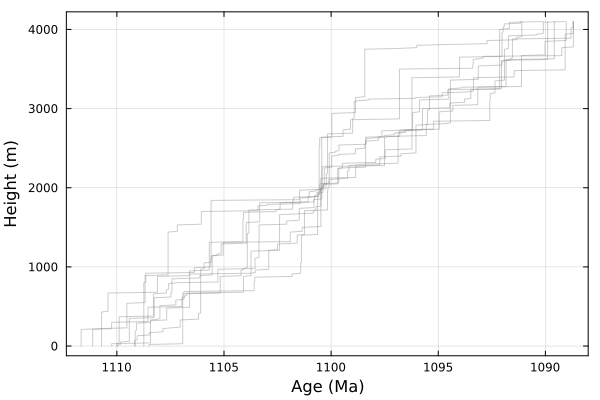

In [19]:
plot_posterior_paths(Mamainse_section, Mamainse_age_model_agedist, Mamainse_age_model_mdl)

## save the age models to a file

In [20]:
# use the mdl.height as index, agedist as the data
Mamainse_age_models_df = DataFrame(hcat(Mamainse_age_model_mdl.Height, Mamainse_age_model_agedist), :auto)
# rename the first three columns to be site, height
rename!(Mamainse_age_models_df, Dict(:x1 => "height"))
Mamainse_age_models_df

Row,height,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16,x17,x18,x19,x20,x21,x22,x23,x24,x25,x26,x27,x28,x29,x30,x31,x32,x33,x34,x35,x36,x37,x38,x39,x40,x41,x42,x43,x44,x45,x46,x47,x48,x49,x50,x51,x52,x53,x54,x55,x56,x57,x58,x59,x60,x61,x62,x63,x64,x65,x66,x67,x68,x69,x70,x71,x72,x73,x74,x75,x76,x77,x78,x79,x80,x81,x82,x83,x84,x85,x86,x87,x88,x89,x90,x91,x92,x93,x94,x95,x96,x97,x98,x99,x100,⋯
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,⋯
1,0.0,1109.11,1109.08,1109.67,1110.33,1110.01,1109.09,1110.44,1111.49,1108.9,1109.27,1109.58,1109.6,1109.52,1111.23,1112.02,1109.74,1108.92,1111.32,1110.46,1108.54,1109.19,1111.28,1109.67,1110.74,1108.49,1108.95,1109.45,1108.27,1110.22,1110.76,1111.57,1110.99,1109.04,1111.28,1110.0,1109.93,1109.74,1112.0,1109.62,1110.48,1108.39,1109.03,1109.68,1108.71,1111.76,1109.72,1111.39,1110.76,1109.14,1110.22,1109.38,1110.37,1110.61,1111.51,1108.24,1110.37,1109.79,1109.93,1109.75,1110.22,1112.27,1109.28,1108.63,1110.43,1110.37,1111.73,1110.24,1110.75,1109.61,1109.86,1109.51,1109.77,1109.08,1109.69,1110.18,1108.09,1110.34,1109.08,1107.32,1111.36,1109.3,1111.38,1111.23,1110.25,1109.71,1108.4,1110.05,1109.72,1109.89,1111.78,1110.29,1109.1,1108.14,1110.65,1109.59,1110.6,1109.26,1107.62,1110.61,⋯
2,10.0,1109.11,1109.08,1109.67,1110.33,1110.01,1109.09,1110.44,1111.49,1108.9,1109.27,1109.58,1109.6,1109.52,1111.23,1112.02,1109.74,1108.92,1111.32,1110.46,1108.54,1109.19,1111.28,1109.67,1110.74,1108.49,1108.95,1109.45,1108.27,1110.22,1110.76,1110.46,1110.99,1109.04,1111.28,1110.0,1109.93,1109.74,1112.0,1109.62,1110.48,1108.39,1109.03,1109.68,1108.71,1111.76,1109.44,1111.39,1110.76,1109.14,1109.95,1109.38,1110.37,1110.61,1111.51,1108.24,1110.37,1109.79,1109.93,1109.75,1109.89,1112.27,1109.28,1108.63,1110.43,1110.37,1111.73,1110.24,1110.75,1109.61,1109.86,1109.51,1109.77,1109.08,1109.69,1110.18,1108.09,1110.34,1109.08,1107.32,1111.36,1109.3,1111.38,1111.23,1110.25,1109.71,1108.4,1110.05,1109.72,1109.89,1111.78,1110.29,1108.89,1108.14,1110.65,1109.59,1110.6,1109.26,1107.62,1110.61,⋯
3,20.0,1109.11,1109.08,1109.67,1110.33,1109.85,1109.09,1110.44,1111.49,1108.9,1109.27,1109.58,1109.58,1109.52,1111.23,1112.02,1109.74,1108.92,1108.76,1110.46,1108.54,1109.19,1111.28,1109.67,1110.74,1108.49,1108.95,1109.45,1108.27,1110.22,1110.76,1110.46,1110.99,1109.04,1111.19,1110.0,1109.93,1109.74,1112.0,1109.62,1110.48,1108.39,1109.03,1109.25,1108.71,1111.76,1109.44,1111.39,1110.76,1109.14,1109.95,1109.38,1110.37,1110.61,1111.51,1108.24,1110.37,1109.79,1109.93,1109.75,1109.89,1112.03,1109.28,1108.63,1110.43,1110.37,1111.73,1110.24,1110.75,1109.61,1109.86,1109.51,1109.77,1109.08,1109.69,1110.18,1108.09,1110.34,1109.08,1107.32,1111.36,1109.3,1111.38,1111.23,1110.25,1109.71,1108.4,1110.05,1109.72,1109.89,1111.78,1110.29,1108.89,1108.14,1109.91,1109.59,1110.6,1109.26,1107.62,1110.61,⋯
4,30.0,1109.11,1109.08,1109.67,1110.33,1109.85,1109.09,1110.44,1111.49,1108.9,1107.62,1109.58,1109.58,1109.52,1110.39,1112.02,1109.74,1108.92,1108.76,1110.46,1108.54,1109.19,1111.28,1109.67,1110.74,1107.8,1108.95,1109.45,1108.27,1110.22,1110.76,1110.46,1110.99,1109.04,1111.19,1110.0,1109.93,1109.74,1112.0,1109.62,1110.48,1108.39,1109.03,1109.25,1108.71,1111.76,1109.44,1111.39,1110.76,1109.14,1109.95,1108.13,111

In [21]:
# write the DataFrame to a csv file
CSV.write(Mamainse_section.Path*"_posterior_ages.csv", Mamainse_age_models_df)

"../../data/age_models_output/Mamainse_Point_Volcanic_Group_posterior_ages.csv"